# ProShares Hedge Replication and Unconstrained Optimization

**FINM 36700 Portfolio and Risk Management Week 2**

**Materials & Sources**
- Course case-study page: [ProShares Replication](https://markhendricks.github.io/finm-portfolio/case_studies/ProShares%20Replication.html)
- Course exercise: [Unconstrained Optimization](https://markhendricks.github.io/finm-portfolio/exercises/Unconstrained%20Optimization.html)
- Case: *ProShares Hedge Replication ETF*


# 1. The ProShares ETF Product

## 1.1 Alternative ETFs

The case separates alternative investments into two broad categories:

- **Alternative asset classes:** exposure to assets outside traditional stocks and bonds.
- **Alternative strategies:** strategies that can use leverage, short positions, derivatives, or other flexible trading rules.

ProShares mainly operates in the second category, packaging strategies that would otherwise require derivatives or direct hedge-fund access into liquid ETFs.


## 1.2 Why invest in hedge funds, and why through an ETF?

The case highlights two main attractions of hedge funds: historically strong risk-adjusted returns and better downside protection than equities. HFRI delivered equity-like returns with substantially lower volatility and experienced smaller drawdowns during major market declines.

Direct hedge-fund investing, however, comes with high minimums, limited liquidity, low transparency, high fees, and manager-selection risk. A replication ETF gives up the possibility of capturing a particular manager's alpha, but offers daily liquidity, transparency, lower fees, and easier diversification.


## 1.3 HFRI, MLFM, MLFM-ES, and HDG

The relationship is easiest to see as HFRI → MLFM → MLFM-ES → HDG.
- **HFRI** is the target hedge-fund index.
- **MLFM** uses rolling regressions to replicate HFRI with six liquid market factors.
- **MLFM-ES** is the tradable version of that factor model.
- **HDG** is the ETF designed to track MLFM-ES.

The case reports roughly 90% correlation between MLFM and HFRI, so the model captures much of the common movement in hedge-fund returns. Its largest loading is the short-term Treasury-bill/cash factor. The main concern is that the model is backward-looking; as a rolling regression can only respond to changes in hedge-fund styles after they appear in the data, the six factors may miss exposures such as credit, carry, volatility, illiquidity, or manager-specific alpha.

## 1.4 The HDG product

HDG tracks MLFM-ES, not HFRI directly. Thus, HDG can track its benchmark closely even if MLFM-ES does not perfectly reproduce hedge-fund returns.

The product can still be useful even if it mainly delivers hedge-fund beta rather than alpha. Systematic hedge-fund exposures may provide diversification, and an ETF offers them more cheaply and transparently than direct hedge-fund investment.

For example, suppose both a traditional hedge fund and HDG earn a 10% gross excess return with 20% volatility. A hedge fund charging 2% of assets plus 20% of positive excess returns leaves roughly 6% net excess return, while a 1% HDG fee leaves roughly 9%. Their net Sharpe ratios are therefore

$$
SR_{HF}=\frac{6\%}{20\%}=0.30,
\quad
SR_{HDG}=\frac{9\%}{20\%}=0.45.
$$

Lower fees can therefore make replication attractive even without manager alpha.


# 2. Analyzing the Data

We now test the replication idea using the supplied monthly data. The main questions are whether the replication products reproduce HFRI's risk-return profile, how closely they track HFRI, and how well a six-factor model performs both in-sample and out-of-sample. We annualize monthly means by 12 and volatilities by $\sqrt{12}$.


## 2.0 Data and helper functions

In [1]:
# Packages needed and locate route to datasets
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from IPython.display import display

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
FREQ_MONTHLY = 12
FREQ_WEEKLY = 52


def find_file(filename):
    candidates = [
        Path(filename),
        Path("data") / filename,
        Path("../data") / filename,
    ]

    path = next((p for p in candidates if p.exists()), None)
    if path is None:
        raise FileNotFoundError(
            f"Could not find {filename}. "
            "Place it in the notebook folder or data/."
        )
    return path


PROSHARES_PATH = find_file("proshares_analysis_data.xlsx")
SPX_PATH = find_file("spx_returns_weekly.xlsx")

print(f"Using ProShares data: {PROSHARES_PATH.resolve()}")
print(f"Using SPX data: {SPX_PATH.resolve()}")


Using ProShares data: /mnt/data/proshares_analysis_data.xlsx
Using SPX data: /mnt/data/spx_returns_weekly.xlsx


In [2]:
hedge = pd.read_excel(
    PROSHARES_PATH,
    sheet_name="hedge_fund_series",
    index_col=0,
    parse_dates=True,
)

merrill = pd.read_excel(
    PROSHARES_PATH,
    sheet_name="merrill_factors",
    index_col=0,
    parse_dates=True,
)

hedge = hedge.rename(columns={
    "HFRIFWI Index": "HFRI",
    "MLEIFCTR Index": "MLFM",
    "MLEIFCTX Index": "MLFM-ES",
    "HDG US Equity": "HDG",
    "QAI US Equity": "QAI",
})

merrill = merrill.rename(columns={
    "SPY US Equity": "SPY",
    "USGG3M Index": "T-Bills",
    "EEM US Equity": "EEM",
    "EFA US Equity": "EFA",
    "EUO US Equity": "EUO",
    "IWM US Equity": "IWM",
})

print(f"Sample: {hedge.index.min():%Y-%m} to {hedge.index.max():%Y-%m}")
print(f"Monthly observations: {len(hedge)}")
display(hedge.tail())

Sample: 2011-08 to 2025-09
Monthly observations: 170


,HFRI,MLFM,MLFM-ES,HDG,QAI
2025-05-31,0.0223,0.0200,0.0197,0.0190,0.0193
2025-06-30,0.0233,0.0115,0.0108,0.0106,0.0153
2025-07-31,0.0097,0.0121,0.0114,0.0091,0.0068
2025-08-31,0.0221,0.0133,0.0130,0.0139,0.0151
2025-09-30,NaN,0.0160,0.0154,0.0150,0.0182


In [3]:
def annualized_performance(returns, freq):
    # Annualized mean, volatility, and Sharpe ratio
    out = pd.DataFrame(index=returns.columns)
    out["Mean"] = returns.mean() * freq
    out["Volatility"] = returns.std(ddof=1) * np.sqrt(freq)
    out["Sharpe"] = out["Mean"] / out["Volatility"]
    return out


def drawdown_details(series):
    # Compute wealth path and drawdown from the running peak
    series = series.dropna()
    wealth = (1 + series).cumprod()
    running_peak = wealth.cummax()
    drawdown = wealth / running_peak - 1

    # Identify the maximum drawdown trough
    trough_date = drawdown.idxmin()
    max_drawdown = drawdown.loc[trough_date]
    peak_level = running_peak.loc[trough_date]

    # Find the peak immediately preceding the trough
    pre_trough = wealth.loc[:trough_date]
    peak_candidates = pre_trough.index[
        np.isclose(pre_trough.values, peak_level, rtol=1e-10, atol=1e-12)
    ]
    peak_date = peak_candidates[-1] if len(peak_candidates) else pre_trough.idxmax()

    # Find when wealth recovers back to the prior peak
    post_trough = wealth.loc[trough_date:]
    recovered = post_trough[post_trough >= peak_level - 1e-12]
    recovery_date = recovered.index[0] if len(recovered) else pd.NaT

    return max_drawdown, peak_date, trough_date, recovery_date


def tail_risk_table(returns):
    # Summary statistics for downside and non-normal return behavior
    out = pd.DataFrame(index=returns.columns)
    out["Skewness"] = returns.skew()
    out["Excess Kurtosis"] = returns.kurt()
    out["VaR (5%)"] = returns.quantile(0.05)

    # CVaR: average return conditional on being below the 5% VaR cutoff
    out["CVaR (5%)"] = [
        returns[col][returns[col] <= returns[col].quantile(0.05)].mean()
        for col in returns.columns
    ]

    # Add maximum drawdown and related dates
    details = [drawdown_details(returns[col]) for col in returns.columns]
    out["Max Drawdown"] = [x[0] for x in details]
    out["Peak Date"] = [x[1] for x in details]
    out["Trough Date"] = [x[2] for x in details]
    out["Recovery Date"] = [x[3] for x in details]

    return out


def benchmark_regression_table(returns, benchmark, freq):
    # Regress each return series on the benchmark
    rows = []

    for col in returns.columns:
        data = pd.concat([returns[col], benchmark], axis=1).dropna()
        data.columns = ["asset", "benchmark"]

        model = sm.OLS(
            data["asset"],
            sm.add_constant(data["benchmark"])
        ).fit()

        # Regression outputs
        alpha_monthly = model.params["const"]
        beta = model.params["benchmark"]
        residual_vol = model.resid.std(ddof=1)

        # Risk-adjusted performance measures
        treynor = (data["asset"].mean() * freq) / beta
        info_ratio = (
            alpha_monthly * freq
            / (residual_vol * np.sqrt(freq))
        )

        rows.append([beta, treynor, info_ratio])

    return pd.DataFrame(
        rows,
        index=returns.columns,
        columns=["Market Beta", "Treynor Ratio", "Information Ratio"],
    )


def extreme_correlations(corr):
    # Keep only unique off-diagonal correlation pairs
    pairs = (
        corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
            .stack()
            .sort_values()
    )
    # Return the lowest- and highest-correlation pairs
    return pairs.index[0], pairs.iloc[0], pairs.index[-1], pairs.iloc[-1]

## 2.1 Summary Statistics

In [4]:
hedge_perf = annualized_performance(hedge, FREQ_MONTHLY)
hedge_perf.round(4)


,Mean,Volatility,Sharpe
HFRI,0.0513,0.0588,0.8722
MLFM,0.0385,0.0552,0.6976
MLFM-ES,0.0365,0.0551,0.6629
HDG,0.0269,0.0574,0.4684
QAI,0.0288,0.0498,0.5783


**Takeaway.** HFRI has the strongest standalone performance in the sample, with the highest annualized mean and Sharpe ratio. The replication indexes have similar volatility but somewhat lower returns, while the investable ETFs lag further. Between the two ETFs, QAI has the stronger standalone profile because it combines a slightly higher mean with lower volatility.


## 2.2 Tail Risk

In [5]:
hedge_tail = tail_risk_table(hedge)

# Keep dates intact and round only the numeric columns
hedge_tail_display = hedge_tail.copy()
numeric_cols = [
    "Skewness", "Excess Kurtosis", "VaR (5%)",
    "CVaR (5%)", "Max Drawdown"
]
hedge_tail_display[numeric_cols] = hedge_tail_display[numeric_cols].round(4)
hedge_tail_display


,Skewness,Excess Kurtosis,VaR (5%),CVaR (5%),Max Drawdown,Peak Date,Trough Date,Recovery Date
HFRI,-0.9483,5.6574,-0.0240,-0.0360,-0.1155,2019-12-31,2020-03-31,2020-08-31
MLFM,-0.2900,1.6309,-0.0270,-0.0350,-0.1243,2021-06-30,2022-09-30,2024-02-29
MLFM-ES,-0.2735,1.5898,-0.0270,-0.0349,-0.1244,2021-06-30,2022-09-30,2024-02-29
HDG,-0.2749,1.7765,-0.0299,-0.0368,-0.1407,2021-06-30,2022-09-30,2024-07-31
QAI,-0.4335,1.4492,-0.0172,-0.0310,-0.1377,2021-06-30,2022-09-30,2024-02-29


**Takeaway.** HFRI has much stronger negative skewness and excess kurtosis than the replication products, even though its 5% VaR is relatively mild. This suggests occasional sharp downside events that volatility alone does not capture. HDG has the deepest maximum drawdown in the sample, while QAI has somewhat milder VaR and CVaR. Thus, the replication products do not uniformly improve HFRI's tail behavior.


## 2.3 Exposure to SPY

We regress each hedge-fund series on SPY and compare market beta, Treynor ratio, and information ratio.


In [6]:
spy = merrill["SPY"]

hedge_reg = benchmark_regression_table(
    hedge,
    spy,
    FREQ_MONTHLY,
)

hedge_reg

,Market Beta,Treynor Ratio,Information Ratio
HFRI,0.3463,0.1481,0.0553
MLFM,0.3425,0.1125,-0.4364
MLFM-ES,0.3415,0.1070,-0.5105
HDG,0.3506,0.0767,-0.8624
QAI,0.3014,0.0956,-0.5978


**Takeaway.** All five series have market betas around 0.30–0.35, consistent with the case's claim that hedge-fund exposure is much less equity-sensitive than SPY. HFRI is the only series with a slightly positive information ratio. The replication indexes and ETFs have negative information ratios, indicating weaker performance after controlling for their SPY exposure. Between HDG and QAI, QAI has lower market beta and a less negative information ratio.


## 2.4 Comparing the Series

SPY earns a much higher average return over this sample, but it also carries substantially more volatility and worse downside risk than the hedge-fund series.

Between HDG and QAI, QAI performs better on most standalone measures: it has a higher mean, lower volatility, higher Sharpe ratio, milder tail losses, lower beta, and a less negative information ratio. HDG's strength is instead its close tracking of the Merrill Lynch replication indexes.

More broadly, MLFM, MLFM-ES, and HDG reproduce several important features of HFRI: relatively low equity beta, similar volatility, and high correlation. What they do not reproduce as well is HFRI's return premium or its tail shape, which is consistent with the idea that liquid factors can capture hedge-fund beta without necessarily capturing manager alpha or less liquid risk premia.


## 2.5 Correlations

In [7]:
corr_assets = pd.concat([hedge, spy], axis=1)
corr = corr_assets.corr()
print("Correlation Matrix:")
print(corr.round(3).to_string())

low_pair, low_corr, high_pair, high_corr = extreme_correlations(corr)

print(
    f"\nHighest correlation: {high_pair[0]} / {high_pair[1]} = {high_corr:.3f}"
)
print(
    f"Lowest correlation: {low_pair[0]} / {low_pair[1]} = {low_corr:.3f}"
)

Correlation Matrix:
          HFRI   MLFM  MLFM-ES    HDG    QAI    SPY
HFRI    1.0000 0.9010   0.9000 0.8900 0.8580 0.8460
MLFM    0.9010 1.0000   1.0000 0.9880 0.8940 0.8890
MLFM-ES 0.9000 1.0000   1.0000 0.9880 0.8930 0.8890
HDG     0.8900 0.9880   0.9880 1.0000 0.8790 0.8760
QAI     0.8580 0.8940   0.8930 0.8790 1.0000 0.8680
SPY     0.8460 0.8890   0.8890 0.8760 0.8680 1.0000

Highest correlation: MLFM / MLFM-ES = 1.000
Lowest correlation: HFRI / SPY = 0.846


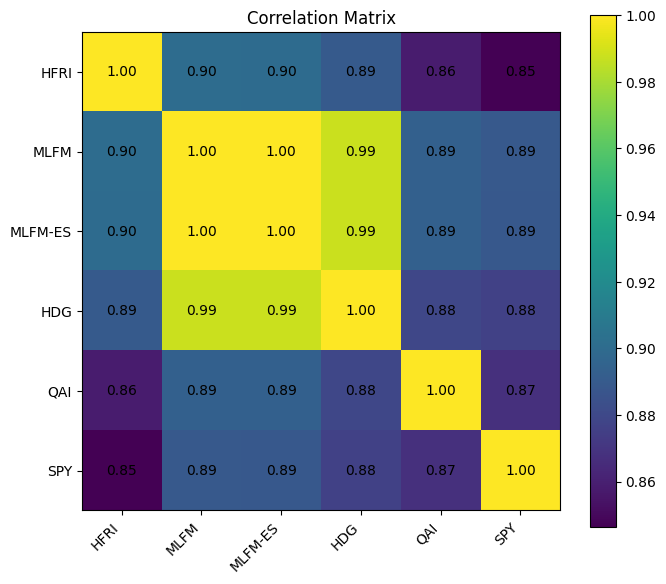

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(corr.values)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")

ax.set_title("Correlation Matrix")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

**Takeaway.** MLFM and MLFM-ES are almost perfectly correlated, which is expected for two implementations of the same factor model. HDG also tracks both very closely.

HFRI is less tightly linked to the replication products, and its lowest correlation in this set is with SPY. Thus, the replication captures much of the common movement in hedge-fund returns without simply becoming an equity-market position.


## 2.6 Full-Sample HFRI Replication

We estimate the unrestricted factor model

$$
r_t^{HFRI}
=
\alpha
+
x_t^\top\beta
+
\epsilon_t,
$$

using the six factors in the `merrill_factors` tab. The fitted value $\hat r_t^{HFRI}$ is our factor-based replication.


In [9]:
factor_cols = ["SPY", "T-Bills", "EEM", "EFA", "EUO", "IWM"]

reg_data = pd.concat(
    [hedge["HFRI"], merrill[factor_cols]],
    axis=1,
).dropna()

hfri_model = sm.OLS(
    reg_data["HFRI"],
    sm.add_constant(reg_data[factor_cols]),
).fit()

# Copy the parameter vector before formatting so the fitted model is not mutated
replication_params = hfri_model.params.copy().to_frame("Estimate")
replication_params = replication_params.rename(
    index={"const": "Intercept (monthly)"}
)

tracking_error = hfri_model.resid.std(ddof=1) * np.sqrt(FREQ_MONTHLY)

print("Regression Estimates:")
print(replication_params.round(4).to_string())

print(f"\nIntercept annualized: {hfri_model.params['const'] * FREQ_MONTHLY:.2%}")
print(f"R-squared: {hfri_model.rsquared:.4f}")
print(f"Annualized tracking error: {tracking_error:.2%}")


Regression Estimates:
                     Estimate
Intercept (monthly)    0.0011
SPY                    0.0435
T-Bills                0.3249
EEM                    0.0856
EFA                    0.0740
EUO                    0.0296
IWM                    0.1458

Intercept annualized: 1.38%
R-squared: 0.8427
Annualized tracking error: 2.33%


**Takeaway.** The six-factor regression explains a large share of HFRI's monthly variation. The estimated positions are also moderate rather than extreme: the largest loading is the T-bill factor, followed by IWM, while the remaining factor betas are all well below one in absolute value. This suggests that a relatively simple set of liquid exposures can explain much of HFRI without requiring implausibly large long-short positions.


## 2.7 Rolling 60-Month Out-of-Sample Replication

The full-sample regression uses the entire history at once. To test the model more realistically, we estimate each month's replication using only the previous 60 months, then roll the window forward one month at a time.


In [10]:
def rolling_replication(target, factors, window=60):
    data = pd.concat(
        [target.rename("Target"), factors],
        axis=1,
    ).dropna()

    predictions = []

    for i in range(window, len(data)):
        train = data.iloc[i-window:i]
        test = data.iloc[i:i+1]

        model = sm.OLS(
            train["Target"],
            sm.add_constant(train[factors.columns], has_constant="add"),
        ).fit()

        x_test = sm.add_constant(
            test[factors.columns],
            has_constant="add",
        )

        predictions.append(
            (data.index[i], float(model.predict(x_test).iloc[0]))
        )

    predicted = pd.Series(
        dict(predictions),
        name="OOS Replication",
    ).sort_index()

    actual = data.loc[predicted.index, "Target"]
    return actual, predicted


hfri_oos, replication_oos = rolling_replication(
    hedge["HFRI"],
    merrill[factor_cols],
    window=60,
)

# OOS errors
oos_error = hfri_oos - replication_oos

# Full-sample OLS estimated only over the same months used in the OOS comparison
same_period = pd.concat(
    [hedge["HFRI"], merrill[factor_cols]],
    axis=1,
).dropna().loc[hfri_oos.index]

same_period_model = sm.OLS(
    same_period["HFRI"],
    sm.add_constant(same_period[factor_cols]),
).fit()

same_period_replication = pd.Series(
    same_period_model.predict(sm.add_constant(same_period[factor_cols])),
    index=same_period.index,
    name="Full-Sample OLS Replication",
)

same_period_error = hfri_oos - same_period_replication

oos_stats = pd.DataFrame({
    "Out-of-Sample": [
        hfri_oos.corr(replication_oos),
        1 - (oos_error ** 2).sum()
        / ((hfri_oos - hfri_oos.mean()) ** 2).sum(),
        oos_error.std(ddof=1) * np.sqrt(FREQ_MONTHLY),
        hfri_oos.mean() * FREQ_MONTHLY,
        replication_oos.mean() * FREQ_MONTHLY,
    ],
    "Full-Sample OLS, Same Months": [
        hfri_oos.corr(same_period_replication),
        same_period_model.rsquared,
        same_period_error.std(ddof=1) * np.sqrt(FREQ_MONTHLY),
        hfri_oos.mean() * FREQ_MONTHLY,
        same_period_replication.mean() * FREQ_MONTHLY,
    ],
}, index=[
    "Correlation with HFRI",
    "R-squared",
    "Tracking Error (annualized)",
    "HFRI Mean (annualized)",
    "Replication Mean (annualized)",
])

oos_stats.round(4)


,Out-of-Sample,"Full-Sample OLS, Same Months"
Correlation with HFRI,0.9013,0.9241
R-squared,0.8055,0.8539
Tracking Error (annualized),0.0275,0.0242
HFRI Mean (annualized),0.0641,0.0641
Replication Mean (annualized),0.0479,0.0641


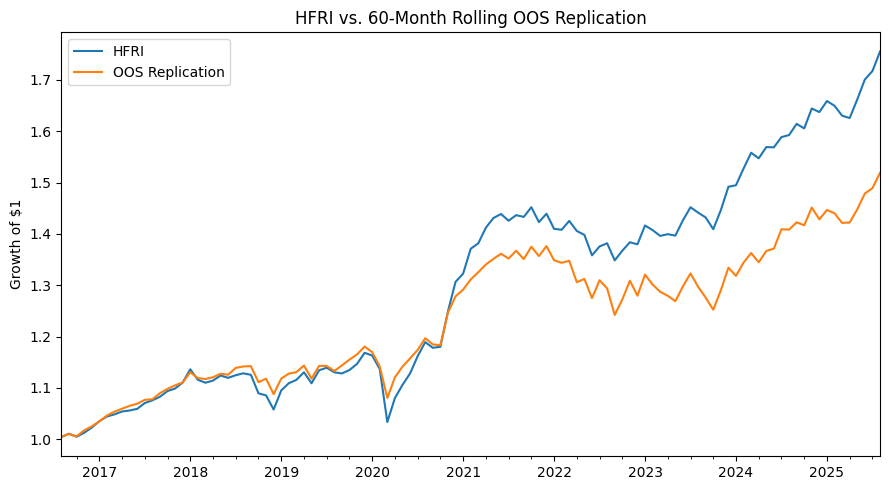

In [11]:
oos_wealth = pd.concat(
    [hfri_oos.rename("HFRI"), replication_oos],
    axis=1,
)
oos_wealth = (1 + oos_wealth).cumprod()

ax = oos_wealth.plot(figsize=(9, 5))
ax.set_title("HFRI vs. 60-Month Rolling OOS Replication")
ax.set_ylabel("Growth of $1")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

**Takeaway.** The OOS replication remains strong, with correlation around 0.90 and an OOS $R^2$ around 0.81. The same-period full-sample regression performs only modestly better, so the factor exposures appear reasonably stable rather than being driven entirely by hindsight.

The main gap is in the level of returns. The OOS replication captures HFRI's month-to-month movements well but understates its average return, reinforcing the distinction between replicating hedge-fund **beta** and reproducing the full realized return of the hedge-fund index.


# Unconstrained Optimization Exercise

The second exercise uses weekly returns for ten large-cap stocks plus SPY. We annualize with 52 periods per year.


## Data and helper functions

In [12]:
TICKS = [
    "AAPL", "NVDA", "MSFT", "GOOGL", "AMZN",
    "META", "TSLA", "AVGO", "BRK/B", "LLY",
]
TICK_ETF = "SPY"

stock_info = pd.read_excel(
    SPX_PATH,
    sheet_name="spx names",
).set_index("ticker")

weekly = pd.read_excel(
    SPX_PATH,
    sheet_name="spx returns",
    index_col="date",
    parse_dates=True,
)[TICKS]

weekly_bench = pd.read_excel(
    SPX_PATH,
    sheet_name="additional returns",
    index_col="date",
    parse_dates=True,
)

weekly[TICK_ETF] = weekly_bench[TICK_ETF]

display(
    stock_info.loc[TICKS, ["name", "gics_sector_name", "mkt cap"]]
              .rename(columns={
                  "name": "Name",
                  "gics_sector_name": "Sector",
                  "mkt cap": "Market Capitalization",
              })
)

print(f"Sample: {weekly.index.min():%Y-%m-%d} to {weekly.index.max():%Y-%m-%d}")
print(f"Weekly observations: {len(weekly)}")

,Name,Sector,Market Capitalization
ticker,,,
AAPL,Apple Inc,Information Technology,"4,631,217,093,920.0000"
NVDA,NVIDIA Corp,Information Technology,"5,105,232,000,000.0000"
MSFT,Microsoft Corp,Information Technology,"2,860,690,204,510.3999"
GOOGL,Alphabet Inc,Communication Services,"4,335,816,321,618.8198"
AMZN,Amazon.com Inc,Consumer Discretionary,"2,639,149,229,028.2402"
META,Meta Platforms Inc,Communication Services,"1,698,738,259,269.8401"
TSLA,Tesla Inc,Consumer Discretionary,"1,531,433,965,638.9600"
AVGO,Broadcom Inc,Information Technology,"1,902,889,351,794.0601"
BRK/B,Berkshire Hathaway Inc,Financials,"1,064,448,332,671.6700"


Sample: 2015-07-10 to 2026-06-26
Weekly observations: 573


# 1. Risk Statistics

## 1.1 Standalone Performance and Risk


In [13]:
def risk_statistics(returns, freq):
    out = annualized_performance(returns, freq)
    out["Skewness"] = returns.skew()

    # Pandas reports excess kurtosis, with a normal distribution equal to 0
    out["Excess Kurtosis"] = returns.kurt()

    out["Max Drawdown"] = [
        drawdown_details(returns[col])[0]
        for col in returns.columns
    ]
    return out


weekly_risk = risk_statistics(weekly, FREQ_WEEKLY)
weekly_risk.round(4)


,Mean,Volatility,Sharpe,Skewness,Excess Kurtosis,Max Drawdown
AAPL,0.2485,0.2776,0.8952,-0.1821,1.8047,-0.3464
NVDA,0.6453,0.4544,1.4202,0.3509,1.4917,-0.6594
MSFT,0.2353,0.2378,0.9894,0.1327,1.6850,-0.3505
GOOGL,0.2698,0.2873,0.9392,0.5326,3.1040,-0.4186
AMZN,0.2613,0.3045,0.8581,-0.0872,1.3419,-0.5483
META,0.2320,0.3575,0.6491,0.0370,3.4901,-0.7603
TSLA,0.4375,0.5797,0.7548,0.5593,1.6335,-0.7225
AVGO,0.3939,0.3825,1.0297,0.6429,3.2722,-0.4004
BRK/B,0.1348,0.1882,0.7164,-0.1865,2.5339,-0.2648
LLY,0.3014,0.2982,1.0107,0.1383,1.9761,-0.3448


## 1.2 Which looks most attractive?

On a standalone basis, **NVDA** is the most attractive investment in the sample. It has the highest Sharpe ratio by a wide margin and positive skewness, although this comes with a very large historical drawdown.

**META** is the least attractive on a risk-adjusted basis. Its return is respectable, but its lower Sharpe ratio and deepest maximum drawdown make the risk-return tradeoff much weaker.


## 1.3 Relative to SPY

We regress each stock on SPY and report annualized alpha, beta, information ratio, and $R^2$.


In [14]:
def regression_vs_spy(returns, benchmark="SPY", freq=52):
    rows = []

    for col in returns.columns:
        if col == benchmark:
            rows.append([0.0, 1.0, np.nan, 1.0])
            continue

        data = returns[[col, benchmark]].dropna()

        model = sm.OLS(
            data[col],
            sm.add_constant(data[benchmark]),
        ).fit()

        alpha_ann = model.params["const"] * freq
        beta = model.params[benchmark]
        residual_vol_ann = model.resid.std(ddof=1) * np.sqrt(freq)
        info_ratio = alpha_ann / residual_vol_ann

        rows.append([
            alpha_ann,
            beta,
            info_ratio,
            model.rsquared,
        ])

    return pd.DataFrame(
        rows,
        index=returns.columns,
        columns=["Alpha", "Beta", "Information Ratio", "R-squared"],
    )


weekly_reg = regression_vs_spy(weekly, freq=FREQ_WEEKLY)
weekly_reg.round(4)


,Alpha,Beta,Information Ratio,R-squared
AAPL,0.0865,1.1161,0.4247,0.4618
NVDA,0.3960,1.7179,1.1329,0.4083
MSFT,0.0878,1.0162,0.5337,0.5216
GOOGL,0.1096,1.1039,0.5016,0.4217
AMZN,0.1006,1.1066,0.4189,0.3773
META,0.0604,1.1824,0.2038,0.3125
TSLA,0.1836,1.7490,0.3683,0.2601
AVGO,0.1873,1.4231,0.6297,0.3955
BRK/B,0.0214,0.7818,0.1593,0.4927
LLY,0.2135,0.6058,0.7622,0.1179


**Takeaway.** NVDA again stands out, with both the highest alpha and the highest information ratio relative to SPY. LLY is attractive for a different reason: its beta and $R^2$ are unusually low, so much more of its return is distinct from the broad equity market. If the comparison is based on active return per unit of residual risk, NVDA is the strongest investment in this sample.


# 2. Portfolio Allocation

## 2.1 Correlations

An asset with unusually low correlation to the rest of the investment set can receive extra weight because of its diversification value, even if its standalone mean return is not especially high.


In [15]:
weekly_corr = weekly.corr()
print("Correlation Matrix:")
print(weekly_corr.round(3).to_string())

Correlation Matrix:
        AAPL   NVDA   MSFT  GOOGL   AMZN   META   TSLA   AVGO  BRK/B    LLY    SPY
AAPL  1.0000 0.4820 0.5540 0.5380 0.4590 0.4060 0.4370 0.5070 0.4050 0.1900 0.6800
NVDA  0.4820 1.0000 0.5920 0.4510 0.5460 0.4280 0.4150 0.5730 0.3000 0.1620 0.6390
MSFT  0.5540 0.5920 1.0000 0.6070 0.6290 0.5680 0.4080 0.5330 0.3590 0.2550 0.7220
GOOGL 0.5380 0.4510 0.6070 1.0000 0.5910 0.5100 0.3660 0.4770 0.3380 0.1700 0.6490
AMZN  0.4590 0.5460 0.6290 0.5910 1.0000 0.5270 0.3950 0.4440 0.2700 0.1440 0.6140
META  0.4060 0.4280 0.5680 0.5100 0.5270 1.0000 0.2650 0.4030 0.2750 0.1160 0.5590
TSLA  0.4370 0.4150 0.4080 0.3660 0.3950 0.2650 1.0000 0.3730 0.1980 0.1260 0.5100
AVGO  0.5070 0.5730 0.5330 0.4770 0.4440 0.4030 0.3730 1.0000 0.3030 0.1040 0.6290
BRK/B 0.4050 0.3000 0.3590 0.3380 0.2700 0.2750 0.1980 0.3030 1.0000 0.2970 0.7020
LLY   0.1900 0.1620 0.2550 0.1700 0.1440 0.1160 0.1260 0.1040 0.2970 1.0000 0.3430
SPY   0.6800 0.6390 0.7220 0.6490 0.6140 0.5590 0.5100 0.6290 0.702

In [16]:
low_pair, low_corr, high_pair, high_corr = extreme_correlations(weekly_corr)

avg_corr = (
    (weekly_corr.sum() - 1)
    / (len(weekly_corr.columns) - 1)
).sort_values()

print(f"Lowest pair: {low_pair[0]} / {low_pair[1]} = {low_corr:.3f}")
print(f"Highest pair: {high_pair[0]} / {high_pair[1]} = {high_corr:.3f}")

print("\nLowest average correlations:")
print(avg_corr.head().round(3).to_string())

Lowest pair: AVGO / LLY = 0.104
Highest pair: MSFT / SPY = 0.722

Lowest average correlations:
LLY     0.1910
BRK/B   0.3450
TSLA    0.3490
META    0.4060
AVGO    0.4350


**Takeaway.** LLY has by far the lowest average correlation with the rest of the investment set, so we should expect it to receive extra weight for diversification value. AVGO–LLY is the least-correlated pair, while MSFT–SPY is the most highly correlated.


## 2.2 Tangency Portfolio

For unconstrained mean-variance optimization,

$$
w_{\mathrm{tan}} \propto \Sigma^{-1}\mu.
$$

The weights are normalized to sum to one, but shorting and leverage are unrestricted.


In [17]:
def optimized_weights(returns, dropna=True, scale_cov=1):
    # Drop missing observations if needed
    if dropna:
        returns = returns.dropna()

    # Full covariance matrix and diagonal-only covariance matrix
    cov_full = returns.cov()
    cov_diag = np.diag(np.diag(cov_full))

    # Optional covariance shrinkage
    cov = (
        scale_cov * cov_full
        + (1 - scale_cov) * cov_diag
    )

    # Tangency portfolio: w ∝ Sigma^{-1} mu
    weights = np.linalg.solve(cov, returns.mean())
    weights = weights / weights.sum()

    # Flip direction if expected portfolio return is negative
    if returns.mean().values @ weights < 0:
        weights = -weights

    return pd.Series(
        weights,
        index=returns.columns,
        name="Tangency Weight",
    )

In [18]:
tangency_w = optimized_weights(weekly)

weight_comparison = pd.concat(
    [
        tangency_w,
        weekly_risk["Sharpe"],
    ],
    axis=1,
).sort_values("Tangency Weight", ascending=False)

print(weight_comparison)

       Tangency Weight  Sharpe
BRK/B           1.6962  0.7164
LLY             0.9050  1.0107
NVDA            0.8463  1.4202
GOOGL           0.5513  0.9392
AVGO            0.4543  1.0297
AAPL            0.3532  0.8952
MSFT            0.3013  0.9894
TSLA            0.2005  0.7548
AMZN            0.1292  0.8581
META            0.1002  0.6491
SPY            -4.5376  0.8588


**Takeaway.** The highest-Sharpe stocks generally receive positive weights, but the ranking is far from one-for-one because the optimizer also uses covariance information. LLY receives substantial weight because of its diversification value, while BRK/B receives an even larger allocation despite a much lower individual Sharpe ratio.

The most striking result is the large short position in SPY. Since the ten stocks already contain substantial market exposure, the optimizer uses SPY as a hedge against the common market component.


## 2.3 Optimized Portfolio Performance

In [19]:
tangency_returns = weekly @ tangency_w

tan_mean = tangency_returns.mean() * FREQ_WEEKLY
tan_vol = tangency_returns.std(ddof=1) * np.sqrt(FREQ_WEEKLY)
tan_sharpe = tan_mean / tan_vol

tangency_stats = pd.DataFrame({
    "Tangency Portfolio": [
        f"{tan_mean:.2%}",
        f"{tan_vol:.2%}",
        f"{tan_sharpe:.4f}",
    ]
}, index=["Annualized Mean", "Annualized Volatility", "Annualized Sharpe"])

print(tangency_stats)

                      Tangency Portfolio
Annualized Mean                  102.01%
Annualized Volatility             52.22%
Annualized Sharpe                 1.9536


**Takeaway.** The unconstrained tangency portfolio produces a very high in-sample Sharpe ratio, but it does so with extreme gross exposure and a large SPY short. The result is therefore highly dependent on estimated means and covariances rather than representing an obviously practical portfolio.


## 2.4 Drop the Largest Short

SPY is the largest short position in the original solution. We remove it from the investment set and re-run the optimization.


In [20]:
largest_short = tangency_w.idxmin()
print(f"Largest short position: {largest_short} ({tangency_w.min():.2%})")

weekly_reduced = weekly.drop(columns=largest_short)
reduced_w = optimized_weights(weekly_reduced)

comparison = pd.concat(
    [
        tangency_w.rename("Original"),
        reduced_w.rename("Without Largest Short"),
    ],
    axis=1,
)

comparison.round(4)


Largest short position: SPY (-453.76%)


,Original,Without Largest Short
AAPL,0.3532,0.0062
NVDA,0.8463,0.4049
MSFT,0.3013,-0.1131
GOOGL,0.5513,0.1765
AMZN,0.1292,-0.0344
META,0.1002,-0.0448
TSLA,0.2005,0.0235
AVGO,0.4543,0.1118
BRK/B,1.6962,0.0385
LLY,0.9050,0.4309


In [21]:
reduced_returns = weekly_reduced @ reduced_w

orig_mean = tangency_returns.mean() * FREQ_WEEKLY
orig_vol = tangency_returns.std(ddof=1) * np.sqrt(FREQ_WEEKLY)
orig_sharpe = orig_mean / orig_vol

red_mean = reduced_returns.mean() * FREQ_WEEKLY
red_vol = reduced_returns.std(ddof=1) * np.sqrt(FREQ_WEEKLY)
red_sharpe = red_mean / red_vol

gross_original = tangency_w.abs().sum()
gross_reduced = reduced_w.abs().sum()

cond_original = np.linalg.cond(weekly.cov())
cond_reduced = np.linalg.cond(weekly_reduced.cov())

reduced_stats = pd.DataFrame({
    "Original": [
        f"{orig_mean:.2%}",
        f"{orig_vol:.2%}",
        f"{orig_sharpe:.4f}",
        f"{gross_original:.2%}",
        f"{cond_original:.1f}",
    ],
    "Without Largest Short": [
        f"{red_mean:.2%}",
        f"{red_vol:.2%}",
        f"{red_sharpe:.4f}",
        f"{gross_reduced:.2%}",
        f"{cond_reduced:.1f}",
    ],
}, index=[
    "Annualized Mean",
    "Annualized Volatility",
    "Annualized Sharpe",
    "Gross Exposure",
    "Covariance Condition Number",
])

reduced_stats


,Original,Without Largest Short
Annualized Mean,102.01%,45.39%
Annualized Volatility,52.22%,27.25%
Annualized Sharpe,1.9536,1.6657
Gross Exposure,1007.53%,138.47%
Covariance Condition Number,206.8,30.3


**Takeaway.** Removing SPY changes the solution dramatically. In the original portfolio, SPY is used as a large short against a levered basket of individual stocks, which pushes gross exposure above 1000%. Once SPY is removed, gross exposure falls sharply and the remaining weights become much more moderate.

The covariance matrix is also far better conditioned without SPY. This helps explain the instability of the original solution: SPY is highly correlated with the individual stocks, so the optimizer can create large offsetting positions from relatively small differences in estimated means and covariances. The Sharpe ratio falls only from about 1.95 to 1.67, suggesting that much of the extreme leverage in the original portfolio is an in-sample optimization effect rather than a robust economic allocation.


# Overall Conclusion

The case and the optimization exercise point to a similar broader lesson: a portfolio can often be understood through a smaller set of common risk exposures, but the usefulness of the model depends on how it is applied.

For ProShares, a six-factor model captures much of HFRI's movement and shows that hedge-fund beta can be replicated reasonably well with liquid assets. The remaining gap in returns and tail behavior, however, shows what a simple linear factor model leaves behind.

The unconstrained optimization exercise makes the same point from the portfolio side. Using the full covariance structure can produce an extremely efficient in-sample portfolio, but also very large and unstable long-short positions.

Overall, both exercises are most useful for understanding what drives portfolio returns and risk rather than for following the model mechanically.
